# ==============================
# EXPLORATORY DATA ANALYSIS
# ==============================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/cleaned_staten_island_otp.csv')

In [3]:
df['Month'] = pd.to_datetime(df['Month'])

Describe data

In [4]:
df.describe()

,Month,Delayed Trains,On-Time Trips,On-Time Performance,Delayed Trains (With Boat),On-Time Trips (With Boat),On-Time Performance (With Boat),Scheduled Trips,Incomplete Trips,Trip Complete Percentage,Year,Month_Number
count,1205,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,241.000000,241.000000,1205.000000,1205.000000
mean,2015-12-31 16:19:55.020747008,75.517012,1648.446473,0.958115,101.437344,1622.526141,0.941490,1723.963485,15.817427,99.585892,2015.543568,6.477178
min,2006-01-01 00:00:00,0.000000,30.000000,0.687000,0.000000,30.000000,0.612000,30.000000,0.000000,93.900000,2006.000000,1.000000
25%,2011-01-01 00:00:00,10.000000,512.000000,0.946000,17.000000,491.000000,0.920000,546.000000,3.000000,99.500000,2011.000000,3.000000
50%,2016-01-01 00:00:00,38.000000,801.000000,0.971000,56.000000,792.000000,0.957000,864.000000,10.000000,99.700000,2016.000000,6.000000
75%,2021-01-01 00:00:00,106.000000,3029.000000,0.986000,145.000000,2990.000000,0.977000,3129.000000,20.000000,99.900000,2021.000000,9.000000
max,2026-01-01 00:00:00,779.000000,4161.000000,1.000000,803.000000,4154.000000,1.000000,4197.000000,231.000000,100.000000,2026.000000,12.000000
std,NaN,99.883682,1357.548742,0.043519,122.466107,1340.398041,0.054206,1419.174212,22.533121,0.590099,5.796161,3.464416


# OTP Distribution

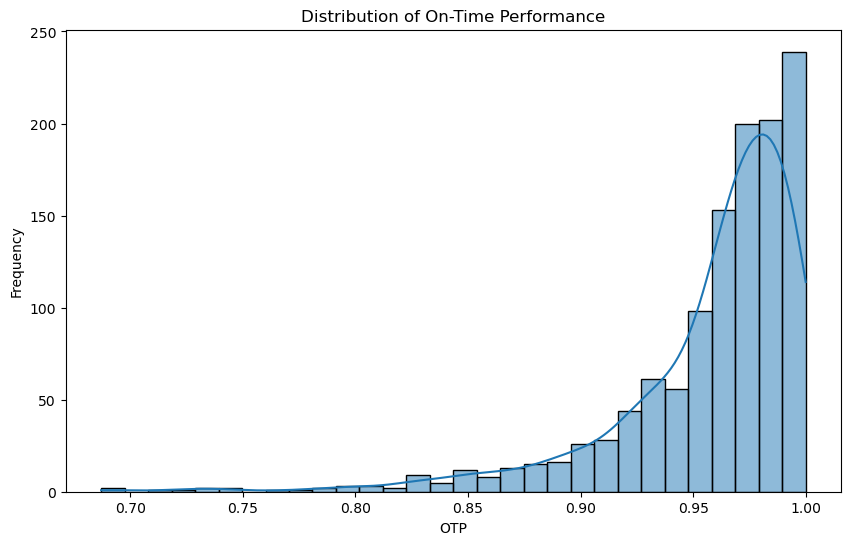

In [5]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(df['On-Time Performance'], bins=30, kde=True)

plt.title('Distribution of On-Time Performance')
plt.xlabel('OTP')
plt.ylabel('Frequency')

plt.show()

# OTP Trend Over Time

In [6]:
monthly_otp = df.groupby('Month')['On-Time Performance'].mean()

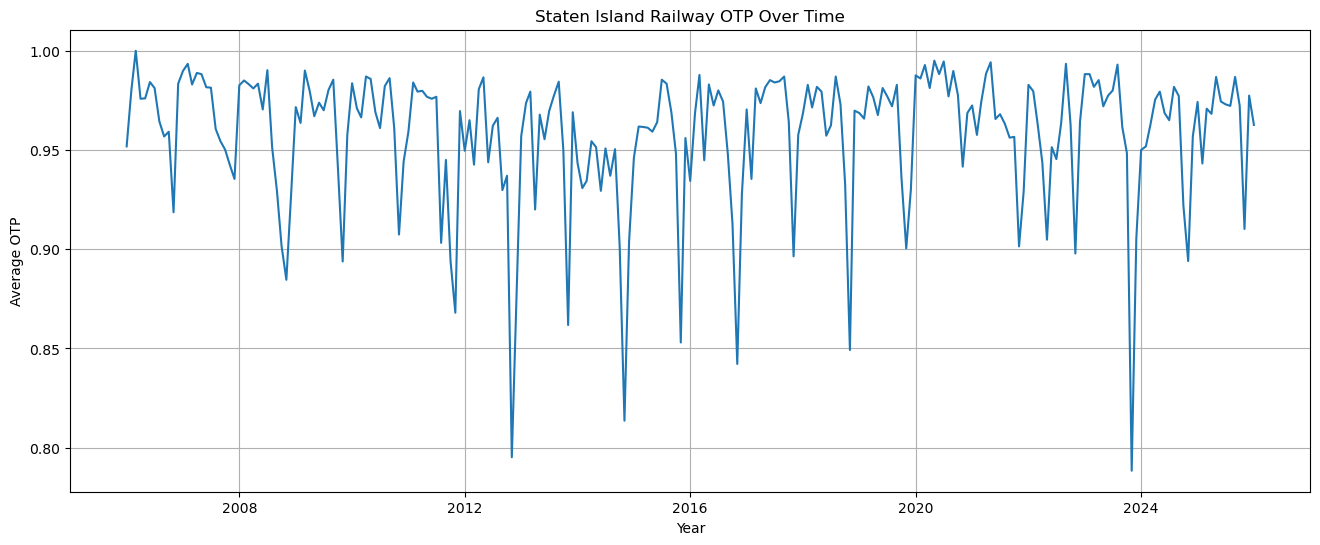

In [7]:
plt.figure(figsize=(16,6))

plt.plot(monthly_otp.index, monthly_otp.values)

plt.title('Staten Island Railway OTP Over Time')
plt.xlabel('Year')
plt.ylabel('Average OTP')

plt.grid(True)

plt.show()

# OTP by Day Time

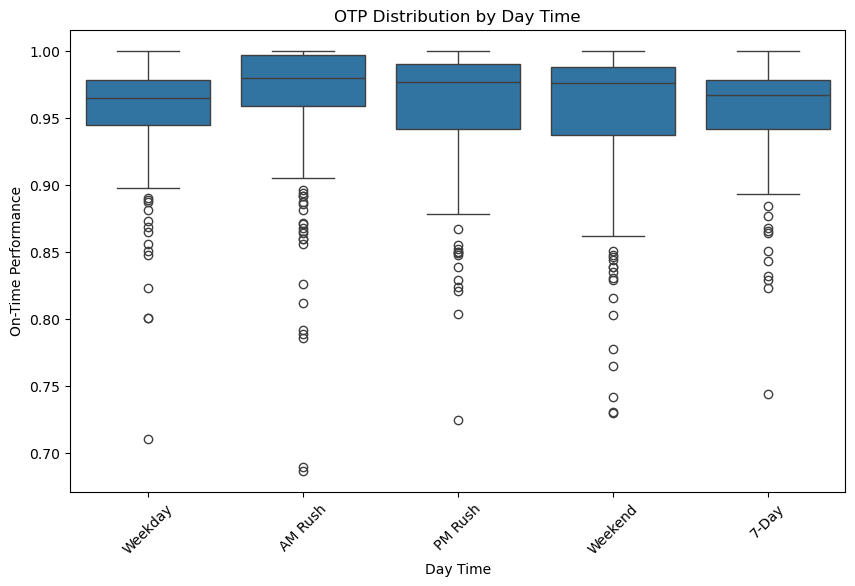

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Day Time',
    y='On-Time Performance'
)

plt.title('OTP Distribution by Day Time')
plt.xticks(rotation=45)

plt.show()

# Delayed Trains Trend

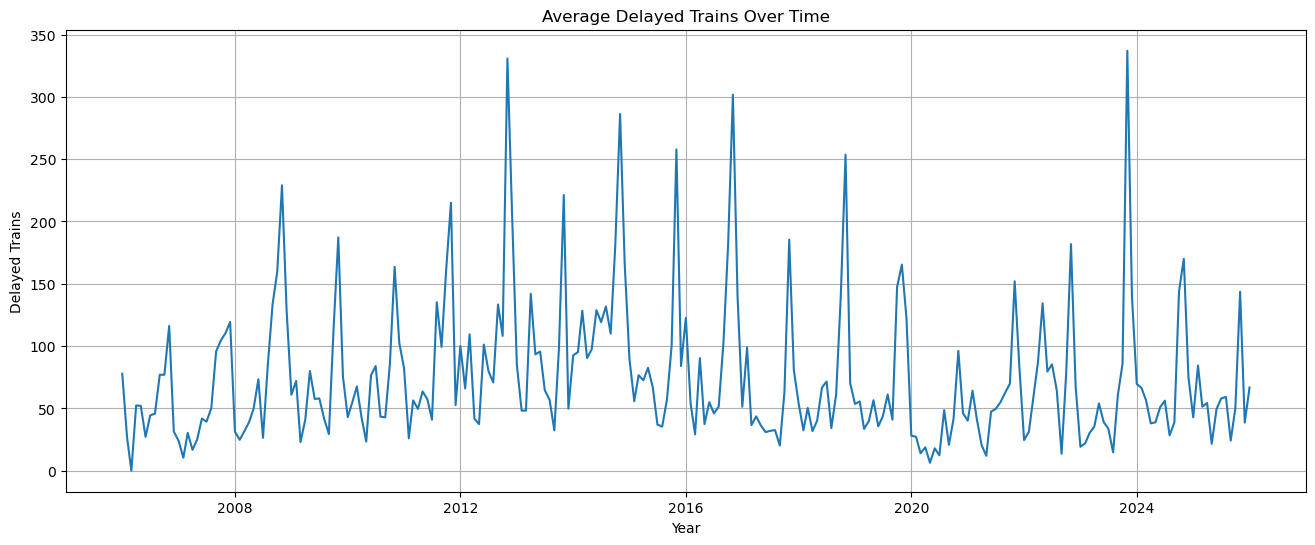

In [9]:
monthly_delays = df.groupby('Month')['Delayed Trains'].mean()

plt.figure(figsize=(16,6))

plt.plot(monthly_delays.index, monthly_delays.values)

plt.title('Average Delayed Trains Over Time')
plt.xlabel('Year')
plt.ylabel('Delayed Trains')

plt.grid(True)

plt.show()

# Correlation Heatmap

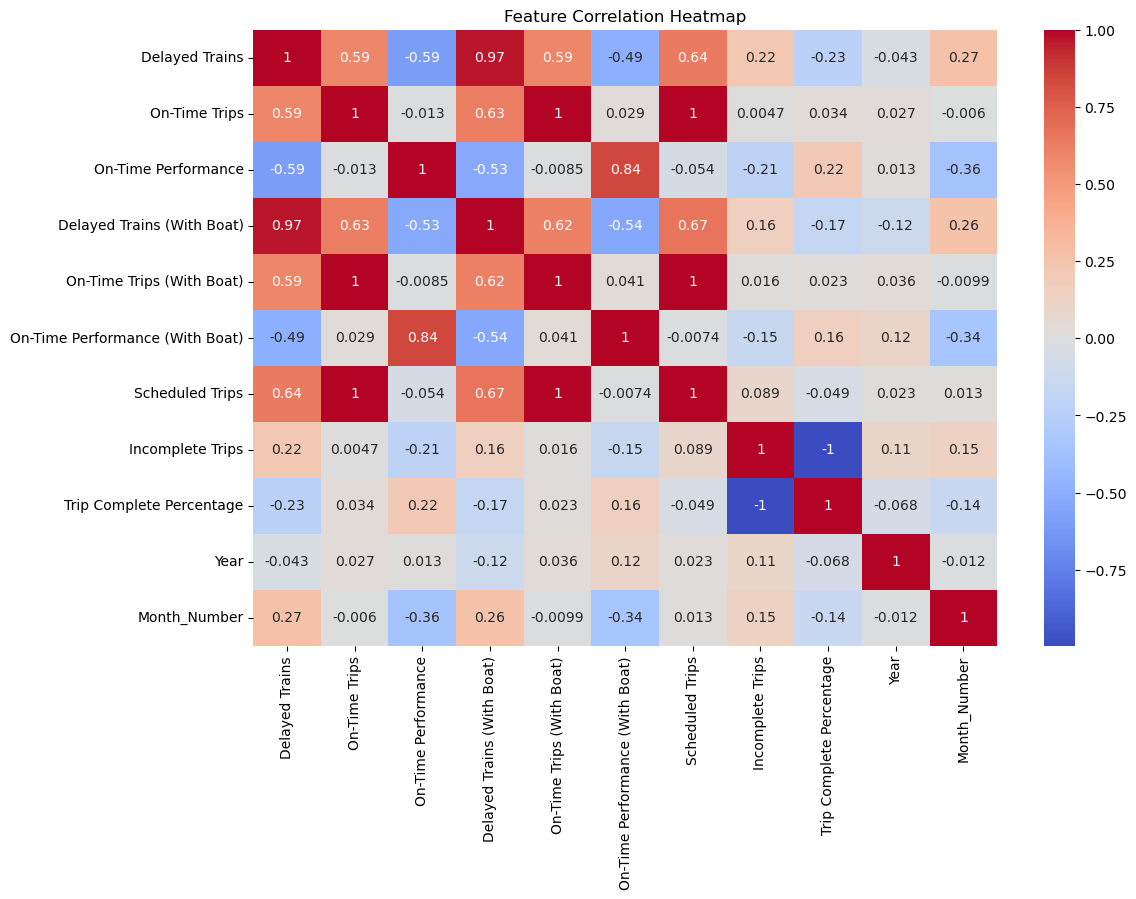

In [10]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')

plt.show()

# Seasonal Analysis

In [11]:
seasonal_otp = df.groupby('Month_Number')['On-Time Performance'].mean()

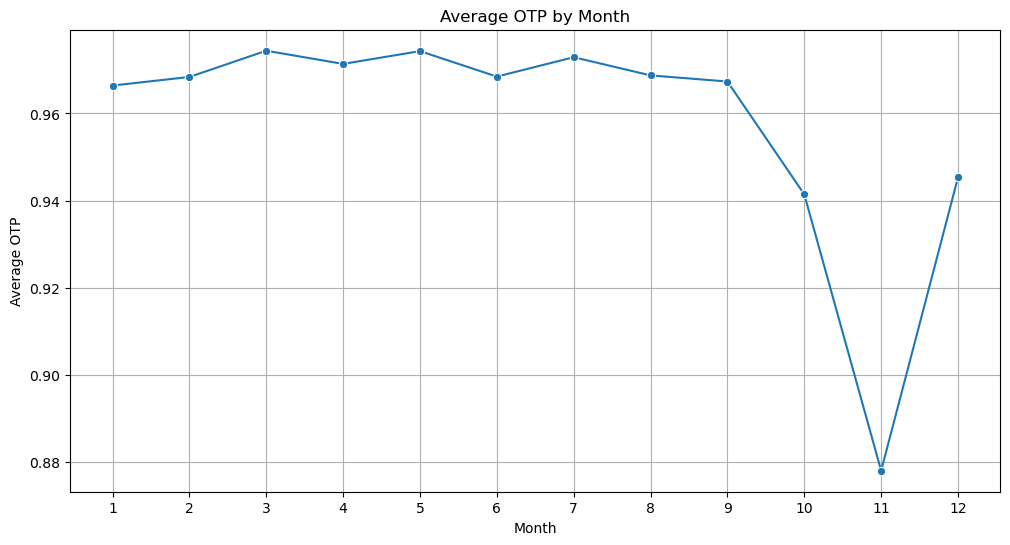

In [12]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=seasonal_otp.index,
    y=seasonal_otp.values,
    marker='o'
)

plt.title('Average OTP by Month')
plt.xlabel('Month')
plt.ylabel('Average OTP')

plt.xticks(range(1,13))

plt.grid(True)

plt.show()

# Identify Worst OTP Months

In [13]:
worst_months = df.nsmallest(10, 'On-Time Performance')

worst_months[
    ['Month', 'Day Time', 'On-Time Performance', 'Delayed Trains']
]

,Month,Day Time,On-Time Performance,Delayed Trains
1071,2023-11-01,AM Rush,0.687,125
531,2014-11-01,AM Rush,0.690,106
410,2012-11-01,Weekday,0.711,666
1072,2023-11-01,PM Rush,0.725,150
338,2011-08-01,Weekend,0.730,176
348,2011-10-01,Weekend,0.731,219
168,2008-10-01,Weekend,0.742,168
414,2012-11-01,7-Day,0.744,779
438,2013-04-01,Weekend,0.765,153
173,2008-11-01,Weekend,0.778,199


In [14]:
import os

os.makedirs('../outputs/figures', exist_ok=True)

In [15]:
plt.savefig('../outputs/figures/otp_trend.png')

<Figure size 640x480 with 0 Axes>